# Zomato Delivery Operations - EDA
## Focus: Demand Forecasting & Delivery Time Prediction

**Project Goal:**
- Part 1: Forecast order
- Part 2: Predict Delivery Time

**Dataset:** Zomato Delivery Operations (Kaggle)

## 0. Setup & Data Loading

In [75]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [76]:
# File paths
data_path = '../data/raw/Zomato Dataset.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(data_path)

print("Data loaded successfully!")
print(f"Orders: {df.shape}")

Data loaded successfully!
Orders: (45584, 20)


## 1. Data Overview & Structure

In [77]:
print("=" * 100)
print("DATASET")
print("=" * 100)
print(df.head(5))
print("=" * 100)
print(df.info())
print("=" * 100)
print(df.describe())

DATASET
       ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
0  0xcdcd      DEHRES17DEL01                 36.0                      4.2   
1  0xd987      KOCRES16DEL01                 21.0                      4.7   
2  0x2784     PUNERES13DEL03                 23.0                      4.7   
3  0xc8b6     LUDHRES15DEL02                 34.0                      4.3   
4  0xdb64      KNPRES14DEL02                 24.0                      4.7   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            30.327968             78.046106                   30.397968   
1            10.003064             76.307589                   10.043064   
2            18.562450             73.916619                   18.652450   
3            30.899584             75.809346                   30.919584   
4            26.463504             80.372929                   26.593504   

   Delivery_location_longitude  Order_Date Time_Orderd Time_Order_

## 2. Data Quality Assessment

**Critical for both forecasting and prediction:**
- Missing values can break time series models
- Understanding data gaps helps define delivery time prediction

In [78]:
# Rename columns for ease of use
df = df.rename(columns={
    "ID": "order_id",
    "Delivery_person_ID": "delivery_person_id",
    "Delivery_person_Age": "delivery_person_age",
    "Delivery_person_Ratings": "delivery_person_rating",
    "Restaurant_latitude": "restaurant_lat",
    "Restaurant_longitude": "restaurant_long",
    "Delivery_location_latitude": "delivery_lat",
    "Delivery_location_longitude": "delivery_long",
    "Order_Date": "order_date",
    "Time_Orderd": "order_time",
    "Time_Order_picked": "pickup_time",
    "Weather_conditions": "weather",
    "Road_traffic_density": "traffic_density",
    "Vehicle_condition": "vehicle_condition",
    "Type_of_order": "order_type",
    "Type_of_vehicle": "vehicle_type",
    "multiple_deliveries": "multiple_deliveries",
    "Festival": "festival",
    "City": "city",
    "Time_taken (min)": "time_taken_min"
})

### Missing values

                        Missing Count  Missing Percent
delivery_person_rating           1908         4.185679
delivery_person_age              1854         4.067217
order_time                       1731         3.797385
city                             1200         2.632503
multiple_deliveries               993         2.178396
weather                           616         1.351351
traffic_density                   601         1.318445
festival                          228         0.500176
order_id                            0         0.000000
delivery_person_id                  0         0.000000
restaurant_lat                      0         0.000000
restaurant_long                     0         0.000000
pickup_time                         0         0.000000
order_date                          0         0.000000
delivery_lat                        0         0.000000
delivery_long                       0         0.000000
vehicle_type                        0         0.000000
order_type

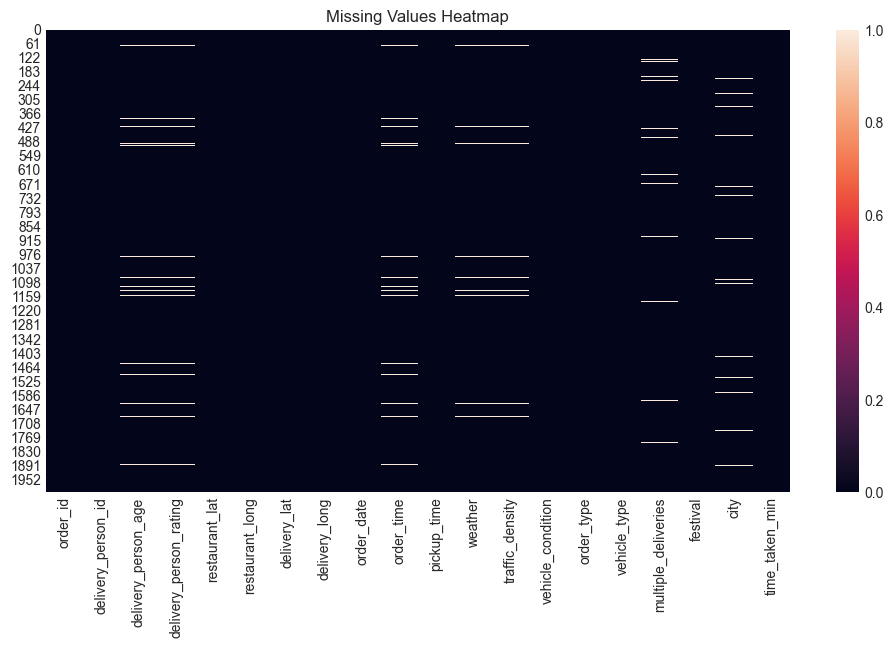

In [79]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Percent': missing_percent}).sort_values(by='Missing Count',ascending=False)

print(missing_df)

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull().head(2000))
plt.title("Missing Values Heatmap")
plt.show()

### Duplicates

In [80]:
duplicates = df.duplicated().sum()
print(f"Dataset duplicated values are: {duplicates}")

Dataset duplicated values are: 0


### Time Data Check

In [81]:
time_columns = ['order_date', 'order_time', 'pickup_time', 'time_taken_min']
for col in time_columns:
    print(df[col].unique())
    print("="*100)

['12-02-2022' '13-02-2022' '04-03-2022' '14-02-2022' '02-04-2022'
 '01-03-2022' '16-03-2022' '20-03-2022' '15-02-2022' '10-03-2022'
 '11-03-2022' '27-03-2022' '26-03-2022' '05-04-2022' '12-03-2022'
 '01-04-2022' '05-03-2022' '11-02-2022' '08-03-2022' '03-04-2022'
 '30-03-2022' '28-03-2022' '18-03-2022' '14-03-2022' '06-04-2022'
 '04-04-2022' '24-03-2022' '19-03-2022' '09-03-2022' '25-03-2022'
 '02-03-2022' '13-03-2022' '29-03-2022' '31-03-2022' '17-03-2022'
 '07-03-2022' '15-03-2022' '16-02-2022' '03-03-2022' '18-02-2022'
 '23-03-2022' '17-02-2022' '06-03-2022' '21-03-2022']
['21:55' '14:55' '17:30' '09:20' '19:50' '20:25' '20:30' '20:40' '21:15'
 '20:20' '22:30' '08:15' '19:30' '12:25' '18:35' '20:35' '23:20' '21:20'
 '23:35' '22:35' '23:25' '13:35' '21:35' '18:55' '14:15' '0.458333333'
 '09:45' '08:40' '0.958333333' '17:25' nan '19:45' '19:10' '10:55' '21:40'
 '0.791666667' '16:45' '11:30' '15:10' '22:45' '22:10' '20:45' '22:50'
 '17:55' '09:25' '20:15' '22:25' '22:40' '23:50' '15:25

In [82]:
def convert_time(x):
    if pd.isna(x):
        return np.nan
    
    if ':' in x:
        return x[:-3] if len(x)>5 else x
    
    try:
        x = float(x)
        return str(int(x*24))+':00'
    except Exception:
        return np.nan

df['order_time'] = df['order_time'].apply(convert_time)
df['pickup_time'] = df['pickup_time'].apply(convert_time)

for col in time_columns:
    print(df[col].unique())
    print("="*100)

['12-02-2022' '13-02-2022' '04-03-2022' '14-02-2022' '02-04-2022'
 '01-03-2022' '16-03-2022' '20-03-2022' '15-02-2022' '10-03-2022'
 '11-03-2022' '27-03-2022' '26-03-2022' '05-04-2022' '12-03-2022'
 '01-04-2022' '05-03-2022' '11-02-2022' '08-03-2022' '03-04-2022'
 '30-03-2022' '28-03-2022' '18-03-2022' '14-03-2022' '06-04-2022'
 '04-04-2022' '24-03-2022' '19-03-2022' '09-03-2022' '25-03-2022'
 '02-03-2022' '13-03-2022' '29-03-2022' '31-03-2022' '17-03-2022'
 '07-03-2022' '15-03-2022' '16-02-2022' '03-03-2022' '18-02-2022'
 '23-03-2022' '17-02-2022' '06-03-2022' '21-03-2022']
['21:55' '14:55' '17:30' '09:20' '19:50' '20:25' '20:30' '20:40' '21:15'
 '20:20' '22:30' '08:15' '19:30' '12:25' '18:35' '20:35' '23:20' '21:20'
 '23:35' '22:35' '23:25' '13:35' '21:35' '18:55' '14:15' '10:00' '09:45'
 '08:40' '22:00' '17:25' nan '19:45' '19:10' '10:55' '21:40' '19:00'
 '16:45' '11:30' '15:10' '22:45' '22:10' '20:45' '22:50' '17:55' '09:25'
 '20:15' '22:25' '22:40' '23:50' '15:25' '10:20' '20:55' 